In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from collections import defaultdict
import matplotlib
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress
from scipy.spatial.distance import cdist
import warnings
import pickle as pkl
import os
warnings.simplefilter("ignore")

In [2]:
from mtu_utils import (
    get_inter_user_metrics,
    get_intra_user_metrics,
    get_sim_users_pairs,
)

In [3]:
from mtu_plots import graph_metrics_models_and_mtu

In [4]:
model_keys = [
    "ideal",
    "content_5",
    #"content_10",
    "pop",
    "mf",
    "sf",
    "random"
]

metric_list = [
    "interaction_history",
    "decisions",
    "utility_history",
    "trait_history",
    "rank_history",
    ]

feed_names = [
    "rand_feed",
    "pop_feed",
    "trend_feed",
    "new_feed",
    "social_feed",
    #"ideal_feed",
    #"any_feed",
    ]

In [5]:
# graphing
plt.style.use('seaborn-whitegrid')
plt.rcParams.update({'font.size': 14})
plotting_sigma = 0.1
mult_sd = 0.25

rs_colors = {
    'content_5' : 'tab:green',
    #'content_10' : 'tab:orange',
    'pop' : 'tab:red',
    'sf' : 'tab:brown',
    'mf' : 'tab:purple',
    'ideal' : 'tab:blue',
    'random' : 'tab:pink'
}

# readable legend keys
model_to_readable = {
    "ideal": "Ideal",
    "content_5": "Content Filtering 5 Tags",
    #"content_10": "Content Filtering 10 Tags",
    "pop": "Popularity",
    "mf" : "Matrix Factorization",
    "sf": "Social Filtering", 
    "random": "Random"
}

feed_names_to_readable = {
    "rand_feed": "Rand",
    "pop_feed": "Pop",
    "trend_feed": "Trend",
    "new_feed": "New",
    "social_feed": "Social",
    #"ideal_feed": "Ideal",
    #"any_feed": "Any",
}

In [6]:
results_file = "/home/salveal/data/salveal/results17"
inpi = 40
all_folder_paths = {feed_folder_path : [results_file + "/" + feed_folder_path + "/r" + str(i) for i in range(6)]
                    for feed_folder_path in feed_names}
all_results_to_readable = {feed: {all_folder_paths[feed][i]: (("RS: "*int(i==0))+str(100-20*i))
                                                                 +"%\n"
                                                                 +(((feed_names_to_readable[feed] + ": ")*int(i==0))+str(20*i))
                                                                 +"%" 
                                for i in range(6)} 
                           for feed in feed_names}
all_results_to_readable["social_feed"][all_folder_paths["social_feed"][5]] = "1%\n99%"

In [7]:
all_final_results = dict()
all_item_attrs = dict()
for feed, folder_paths in all_folder_paths.items():
    final_results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    for folder_path in folder_paths:
        filepath = os.path.join(folder_path, "sim_results.pkl")
        results = pkl.load(open(filepath, "rb"))
        for metric_name, v in results.items():
            for model_name, metric_vals in v.items():
                final_results[metric_name][model_name][folder_path] += np.array(metric_vals).tolist()
    all_final_results[feed] = final_results
    all_item_attrs[feed] = np.array(final_results['item_attrs']['all'][folder_paths[0]])

In [8]:
all_interactions = dict()
all_user_iter_attrs_ideals = dict()
for feed, folder_paths in all_folder_paths.items():
    interactions = dict()
    for mo in model_keys:
        interactions[mo] = dict()
        folder_to_inspect = folder_paths #if mo != "content_reduced" else folder_paths_CBF
        for fo in folder_to_inspect:
            interactions[mo][fo] = np.array(all_final_results[feed]['interaction_history'][mo][fo]) #if mo != "content_reduced" else np.array(final_results_CBF['interaction_history'][mo][fo])
            interactions[mo][fo] = np.transpose(interactions[mo][fo].reshape(interactions[mo][fo].shape[:-1]), axes=[0,2,1])
    all_interactions[feed] = interactions
    # I suspect this last line is the same for all feeds but i'll need to test that
    all_user_iter_attrs_ideals[feed] = np.array([all_item_attrs[feed][i].T[interactions['ideal'][folder_paths[0]][i]] for i in range(interactions['ideal'][folder_paths[0]].shape[0])])

In [9]:
all_decisions = dict()
for feed, folder_paths in all_folder_paths.items():
    decisions = dict()
    for mo in model_keys:
        decisions[mo] = dict()
        folder_to_inspect = folder_paths #if mo != "content_reduced" else folder_paths_CBF
        for fo in folder_to_inspect:
            decisions[mo][fo] = np.array(all_final_results[feed]['decisions'][mo][fo]) #if mo != "content_reduced" else np.array(final_results_CBF['decisions'][mo][fo])
            decisions[mo][fo] = np.transpose(decisions[mo][fo], axes=[0,2,1])
    all_decisions[feed] = decisions

In [10]:
all_utilities = dict()
for feed, folder_paths in all_folder_paths.items():
    utilities = dict()
    for mo in model_keys:
        utilities[mo] = dict()
        folder_to_inspect = folder_paths #if mo != "content_reduced" else folder_paths_CBF
        for fo in folder_to_inspect:
            utilities[mo][fo] = np.array(all_final_results[feed]['utility_history'][mo][fo]) #if mo != "content_reduced" else np.array(final_results_CBF['utility_history'][mo][fo])
            utilities[mo][fo] = np.transpose(utilities[mo][fo], axes=[0,2,1])
    all_utilities[feed] = utilities

In [11]:
all_traits = dict()
for feed, folder_paths in all_folder_paths.items():
    traits = dict()
    for mo in model_keys:
        traits[mo] = dict()
        folder_to_inspect = folder_paths
        for fo in folder_to_inspect:
            traits[mo][fo] = np.array(all_final_results[feed]['trait_history'][mo][fo])
            traits[mo][fo] = np.transpose(traits[mo][fo], axes=[0,2,1,3])
    all_traits[feed] = traits

In [12]:
all_ranks = dict()
for feed, folder_paths in all_folder_paths.items():
    ranks = dict()
    for mo in model_keys:
        ranks[mo] = dict()
        folder_to_inspect = folder_paths
        for fo in folder_to_inspect:
            ranks[mo][fo] = np.array(all_final_results[feed]['rank_history'][mo][fo])
            ranks[mo][fo] = np.transpose(ranks[mo][fo], axes=[0,2,1])
    all_ranks[feed] = ranks

# Getting All Measurement Values

## Utility

In [13]:
all_tot_user_util = dict()
for feed, folder_paths in all_folder_paths.items():
    tot_user_util = dict()
    for mo in all_utilities[feed].keys():
        tot_user_util[mo] = dict()
        for fo in all_utilities[feed][mo].keys():
            tot_user_util[mo][fo] = []
            for i in range(all_utilities[feed][mo][fo].shape[0]):
                re = []
                re.append(all_utilities[feed][mo][fo][i].mean())
                tot_user_util[mo][fo].append(re)
            tot_user_util[mo][fo] = np.array(tot_user_util[mo][fo])
    all_tot_user_util[feed] = tot_user_util

## Diversity

In [14]:
all_inter_user_div = dict()
for feed, _ in all_folder_paths.items():
    inter_user_div = dict()
    for mo in all_interactions[feed].keys():
        inter_user_div[mo] = dict()
        for fo in all_interactions[feed][mo].keys():
            inter_user_div[mo][fo] = []
            for i in range(all_interactions[feed][mo][fo].shape[0]):
                re = []
                user_iter_attrs = all_item_attrs[feed][i].T[all_interactions[feed][mo][fo][i]]
                for j in range(user_iter_attrs.shape[1]):
                    mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
                    user_mean = mean_user_attrs.mean(axis=0)
                    distances = np.linalg.norm(mean_user_attrs - user_mean, axis=1)
                    variance = ((distances**2).sum())/distances.shape[0]
                    re.append(variance**0.5)
                inter_user_div[mo][fo].append(re)
            inter_user_div[mo][fo] = np.array(inter_user_div[mo][fo])
    all_inter_user_div[feed] = inter_user_div

In [15]:
all_intra_user_div = dict()
for feed, _ in all_folder_paths.items():
    intra_user_div = dict()
    for mo in all_interactions[feed].keys():
        intra_user_div[mo] = dict()
        for fo in all_interactions[feed][mo].keys():
            intra_user_div[mo][fo] = []
            for i in range(all_interactions[feed][mo][fo].shape[0]):
                re = []
                user_iter_attrs = all_item_attrs[feed][i].T[all_interactions[feed][mo][fo][i]]
                for j in range(user_iter_attrs.shape[1]-1, user_iter_attrs.shape[1]):
                    mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
                    diff_vectors = np.array([user_iter_attrs[k,:(j+1)] - mean_user_attrs[k] for k in range(user_iter_attrs.shape[0])])
                    distances = np.linalg.norm(diff_vectors, axis=2)
                    variances = ((distances**2).sum(axis=1))/distances.shape[1]
                    re.append((variances**0.5).mean())
                intra_user_div[mo][fo].append(re)
            intra_user_div[mo][fo] = np.array(intra_user_div[mo][fo])
    all_intra_user_div[feed] = intra_user_div

In [16]:
all_homog = dict()
for feed, _ in all_folder_paths.items():
    homog = dict()
    for mo in all_interactions[feed].keys():
        homog[mo] = dict()
        for fo in all_interactions[feed][mo].keys():
            homog[mo][fo] = (all_inter_user_div[feed][mo][fo]**2 + all_intra_user_div[feed][mo][fo]**2)**(-0.5)
    all_homog[feed] = homog

In [17]:
def compute_distance_matrix(set_A, set_B):
    d = set_A[:,np.newaxis,:] - set_B[np.newaxis,:,:]
    d = np.linalg.norm(d, axis=2)
    return d

In [18]:
all_chamfer = dict()
for feed, _ in all_folder_paths.items():
    chamfer = dict()
    for mo in all_interactions[feed].keys():
        chamfer[mo] = dict()
        for fo in all_interactions[feed][mo].keys():
            chamfer[mo][fo] = []
            for i in range(all_interactions[feed][mo][fo].shape[0]):
                re = []
                user_iter_attrs = all_item_attrs[feed][i].T[all_interactions[feed][mo][fo][i]]
                for j in range(user_iter_attrs.shape[1]-1, user_iter_attrs.shape[1]): # sólo última iter pq se tarda mucho
                    f="""
                    mean_user_attrs = user_iter_attrs[:,:(j+1)].mean(axis=1)
                    nearest_users = get_sim_users_pairs(mean_user_attrs)

                    pairs_p_iter_attrs = user_iter_attrs[nearest_users]
                    pair_inter_inter_d = np.linalg.norm(pairs_p_iter_attrs[:,0,:(j+1),np.newaxis,:] 
                                                        - pairs_p_iter_attrs[:,1,np.newaxis,:(j+1),:],
                                                        axis=3)
                    chamfer_iter = np.append(pair_inter_inter_d,
                                             pair_inter_inter_d.transpose((0,2,1)),
                                             axis=0).min(axis=2).mean()
                    
                    ideal_pairs_p_iter_attrs = all_user_iter_attrs_ideals[feed][i,nearest_users]
                    ideal_pair_inter_inter_d = np.linalg.norm(ideal_pairs_p_iter_attrs[:,0,:(j+1),np.newaxis,:]
                                                              - ideal_pairs_p_iter_attrs[:,1,np.newaxis,:(j+1),:],
                                                              axis=3)
                    ideal_chamfer_iter = np.append(ideal_pair_inter_inter_d,
                                                   ideal_pair_inter_inter_d.transpose((0,2,1)),
                                                   axis=0).min(axis=2).mean()
                    """
                    mean_user_attrs = user_iter_attrs[:, :(j+1)].mean(axis=1)
                    nearest_users = get_sim_users_pairs(mean_user_attrs)

                    pairs_p_iter_attrs = user_iter_attrs[nearest_users]

                    # Initialize arrays to store distances
                    pair_inter_inter_d = np.zeros((pairs_p_iter_attrs.shape[0], j+1, j+1))
                    ideal_pair_inter_inter_d = np.zeros((pairs_p_iter_attrs.shape[0], j+1, j+1))

                    # Compute pairwise distances for each pair
                    for p in range(pairs_p_iter_attrs.shape[0]):
                        # Compute distances between pairs_p_iter_attrs[p, 0] and pairs_p_iter_attrs[p, 1]
                        pair_inter_inter_d[p] = cdist(pairs_p_iter_attrs[p, 0, :(j+1)], pairs_p_iter_attrs[p, 1, :(j+1)], metric='euclidean')

                        # Compute distances for the ideal pairs
                        ideal_pairs_p_iter_attrs = all_user_iter_attrs_ideals[feed][i, nearest_users]
                        ideal_pair_inter_inter_d[p] = cdist(ideal_pairs_p_iter_attrs[p, 0, :(j+1)], ideal_pairs_p_iter_attrs[p, 1, :(j+1)], metric='euclidean')

                    min_axis_0 = np.min(pair_inter_inter_d, axis=2)
                    min_axis_1 = np.min(pair_inter_inter_d, axis=1)
                    all_min_values = np.concatenate([min_axis_0.flatten(), min_axis_1.flatten()])
                    chamfer_iter = np.mean(all_min_values)

                    ideal_min_axis_0 = np.min(ideal_pair_inter_inter_d, axis=2)
                    ideal_min_axis_1 = np.min(ideal_pair_inter_inter_d, axis=1)
                    ideal_all_min_values = np.concatenate([ideal_min_axis_0.flatten(), ideal_min_axis_1.flatten()])
                    ideal_chamfer_iter = np.mean(ideal_all_min_values)

                    re.append(ideal_chamfer_iter - chamfer_iter)
                chamfer[mo][fo].append(re)
            chamfer[mo][fo] = np.array(chamfer[mo][fo])
    all_chamfer[feed] = chamfer

## Item Distribution

In [19]:
all_gini = dict()
for feed, _ in all_folder_paths.items():
    gini = dict()
    for mo in all_interactions[feed].keys():
        gini[mo] = dict()
        for fo in all_interactions[feed][mo].keys():
            gini[mo][fo] = []
            for i in range(all_interactions[feed][mo][fo].shape[0]):
                re = []
                for j in range(all_interactions[feed][mo][fo][i].shape[1]-1, all_interactions[feed][mo][fo][i].shape[1]):
                    num_items = (j+1)*inpi
                    user_iter_interactions = all_interactions[feed][mo][fo][i,:,:(j+1)]
                    item_interactions = np.bincount(user_iter_interactions.flatten(), minlength=num_items)
                    item_ranks = np.argsort(np.argsort(-item_interactions)) + 1
                    numerator = (((2*item_ranks) - num_items - 1) * item_interactions).sum()
                    denominator = item_interactions.sum()
                    gini_iter = - numerator / (num_items * denominator)
                    re.append(gini_iter)
                gini[mo][fo].append(re)
            gini[mo][fo] = np.array(gini[mo][fo])
    all_gini[feed] = gini

In [20]:
all_cover = dict()
for feed, _ in all_folder_paths.items():
    cover = dict()
    for mo in all_interactions[feed].keys():
        cover[mo] = dict()
        for fo in all_interactions[feed][mo].keys():
            cover[mo][fo] = []
            for i in range(all_interactions[feed][mo][fo].shape[0]):
                re = []
                for j in range(all_interactions[feed][mo][fo][i].shape[1]-1, all_interactions[feed][mo][fo][i].shape[1]):
                    num_items = (j+1)*inpi
                    user_iter_interactions = all_interactions[feed][mo][fo][i,:,:(j+1)]
                    cover_iter = np.unique(user_iter_interactions).shape[0] / num_items
                    re.append(cover_iter)
                cover[mo][fo].append(re)
            cover[mo][fo] = np.array(cover[mo][fo])
    all_cover[feed] = cover

## Choice Distribution

In [21]:
all_choices = dict()
for feed, _ in all_folder_paths.items():
    choices = dict()
    for mo in all_utilities[feed].keys():
        choices[mo] = dict()
        for fo in all_utilities[feed][mo].keys():
            choices[mo][fo] = []
            for i in range(all_utilities[feed][mo][fo].shape[0]):
                re = []
                re.append(all_decisions[feed][mo][fo][i,0,-1]/(all_utilities[feed][mo][fo].shape[1]*all_decisions[feed][mo][fo].shape[2]))
                choices[mo][fo].append(re)
            choices[mo][fo] = np.array(choices[mo][fo])
    all_choices[feed] = choices

# Plotting

In [22]:
metrics = {
    "mean_util": all_tot_user_util,
    "inter": all_inter_user_div,
    "intra": all_intra_user_div,
    "homog": all_homog,
    "sim_homog": all_chamfer,
    "gini": all_gini,
    "cover": all_cover,
    "choices": all_choices,
}

metrics_no_choices = {
    "mean_util": all_tot_user_util,
    "inter": all_inter_user_div,
    "intra": all_intra_user_div,
    "homog": all_homog,
    "sim_homog": all_chamfer,
    "gini": all_gini,
    "cover": all_cover,
}

[1.  0.8 0.6 0.4 0.2 0. ]
[1.  0.8 0.6 0.4 0.2 0. ]
[1.  0.8 0.6 0.4 0.2 0. ]
[1.  0.8 0.6 0.4 0.2 0. ]
[1.   0.8  0.6  0.4  0.2  0.01]


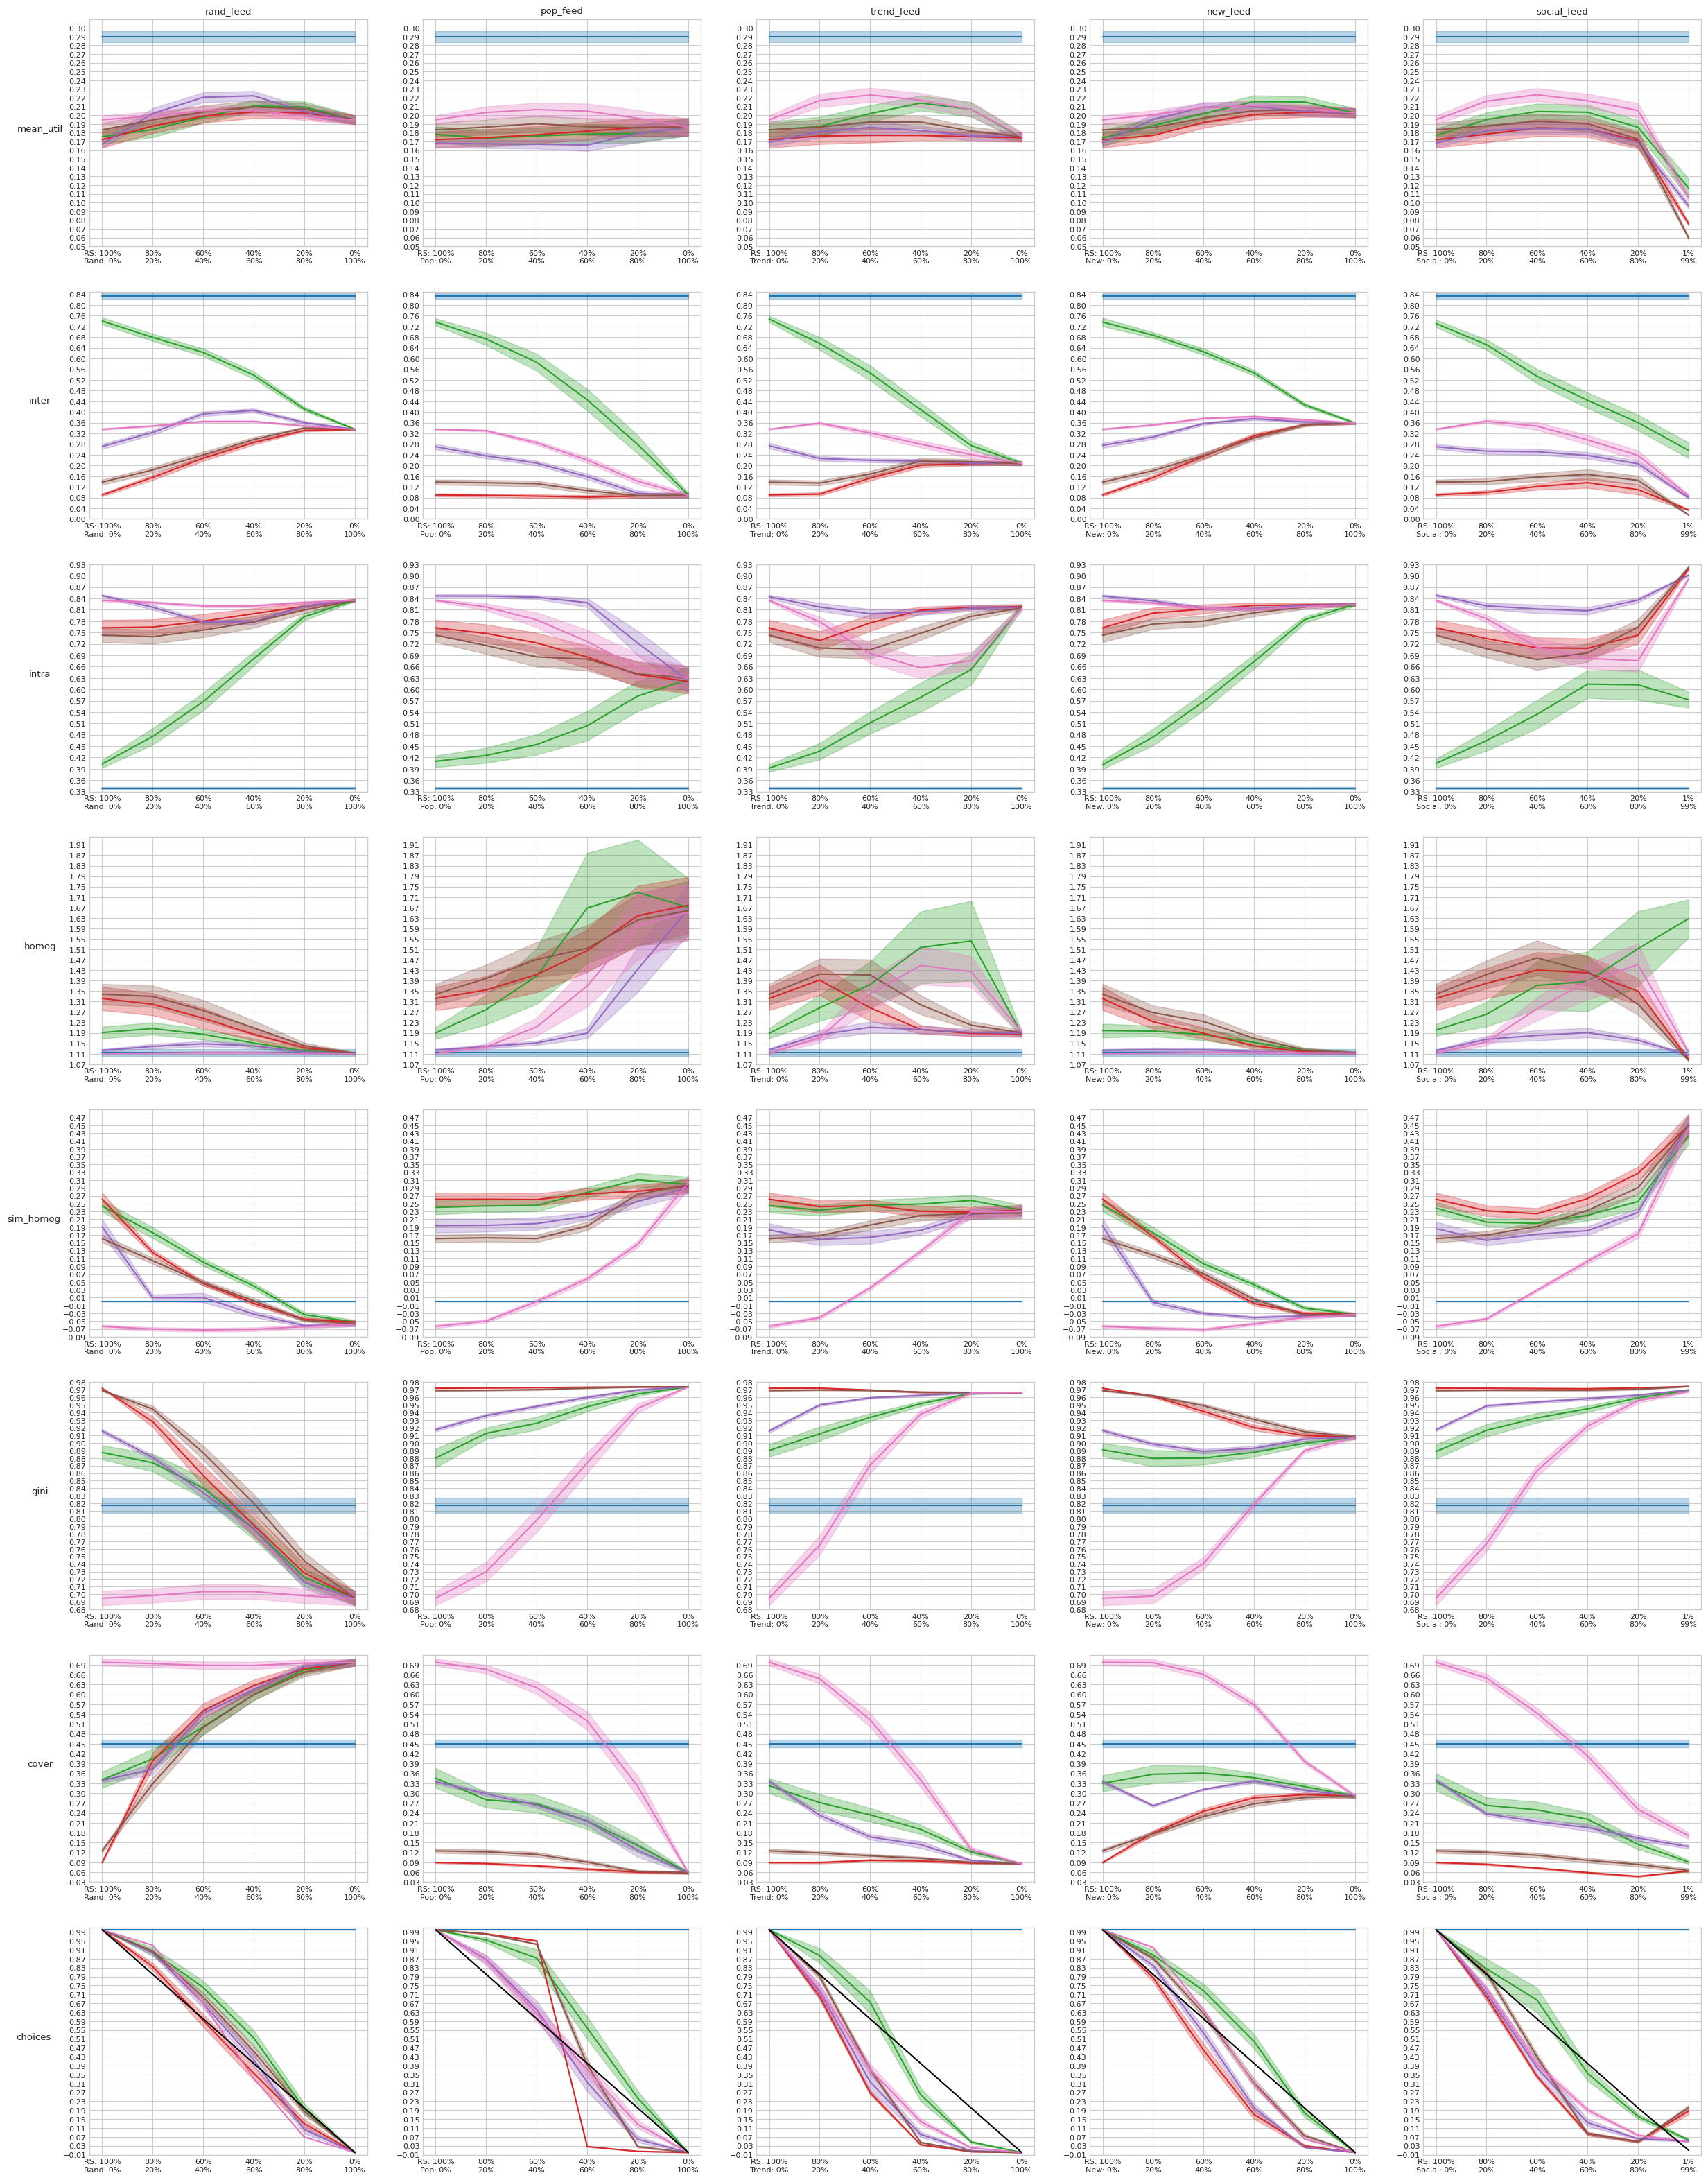

In [ ]:
plt.rcParams.update({'font.size': 8})
fig, axes = plt.subplots(8, 5, figsize=(30, 40))  # 8 rows, 5 columns
fig.subplots_adjust(hspace=0.2, wspace=0.2)
#fig.suptitle('Overall metrics performance of RSs vs Feeds', fontsize=10)
row=-1
for metric_name, v in metrics.items():
    row+=1
    col=-1
    upper_ylim = -10.0
    lower_ylim = 10.0
    for feed in v.keys():
        col+=1
        for mo in v[feed].keys():
            x_axis_labels = all_results_to_readable[feed]
            x_axis = [x_axis_labels[r] for r in list(v[feed][mo].keys())]
            y_axis = np.array(list(v[feed][mo].values()))[:,:,-1]
            if mo == "ideal":
                y_axis[:] = y_axis[0]
            values = gaussian_filter1d(y_axis.mean(axis=1), sigma=plotting_sigma)
            ax = axes[row, col]
            ax.plot(x_axis, values, label=model_to_readable[mo], color=rs_colors[mo])

            std = y_axis.std(axis=1)
            mtus = np.arange(len(std))
            low = values - mult_sd * std
            high = values + mult_sd * std
            low = gaussian_filter1d(low, sigma=plotting_sigma)
            high = gaussian_filter1d(high, sigma=plotting_sigma)
            ax.fill_between(mtus, low, high, color=rs_colors[mo], alpha=0.3)

            upper_ylim = max(high.max(), upper_ylim)
            lower_ylim = min(low.min(), lower_ylim)
        if metric_name == "choices":
            identity = np.append(np.arange(1.0, 0.0, -1/5), 0.01*int(feed == "social_feed"))
            ax.plot(x_axis, identity, color="k")
    col=-1
    upper_ylim = np.round(upper_ylim, 2) + 0.01
    lower_ylim = np.round(lower_ylim, 2) - 0.01
    for feed in v.keys():
        col+=1
        ax = axes[row, col]
        ax.set_ylim((lower_ylim, upper_ylim))
        ax.set_yticks(np.arange(lower_ylim, upper_ylim, np.round((upper_ylim-lower_ylim)/24, 2)))

for ax, col in zip(axes[0], feed_names):
    ax.set_title(col)
for ax, row in zip(axes[:,0], metrics.keys()):
    ax.set_ylabel(row, rotation=0, size='large', labelpad=30)
plt.show()

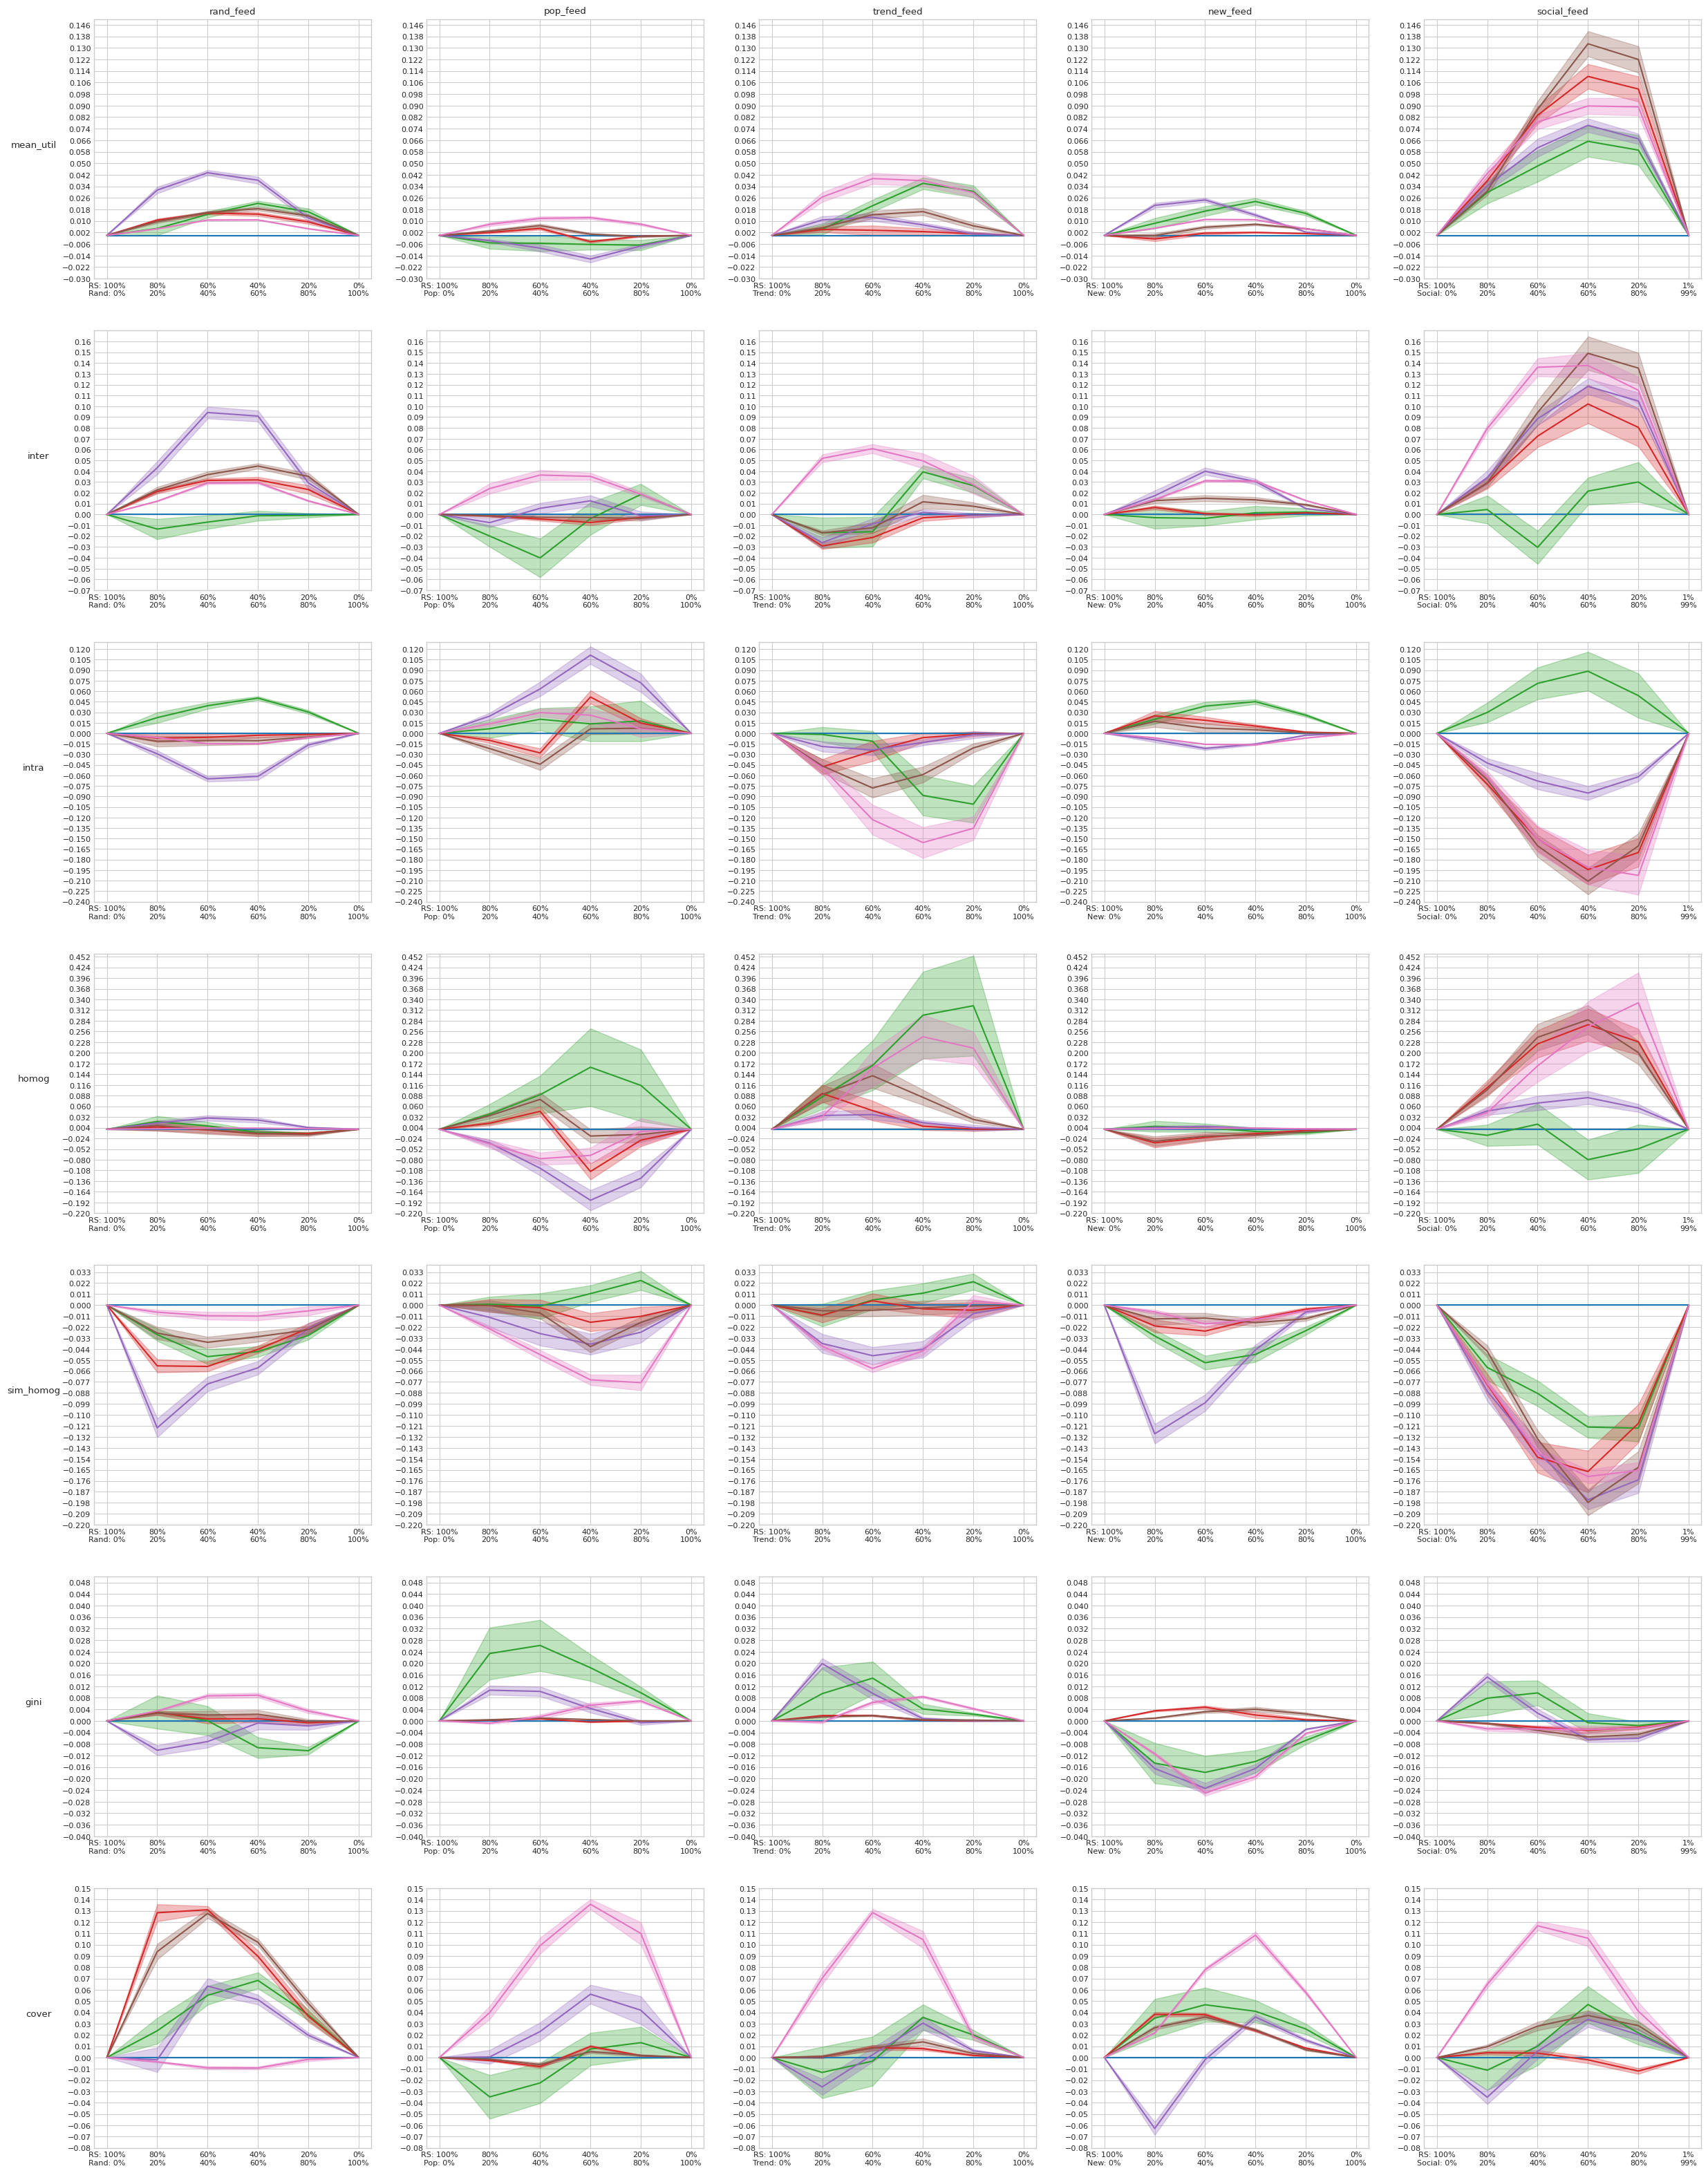

In [ ]:
plt.rcParams.update({'font.size': 8})
fig, axes = plt.subplots(7, 5, figsize=(30, 40))  # 7 rows, 5 columns
fig.subplots_adjust(hspace=0.2, wspace=0.2)
#fig.suptitle('Overall metrics performance of RSs vs Feeds', fontsize=10)
row=-1
for metric_name, v in metrics_no_choices.items():
    row+=1
    col=-1
    upper_ylim = -10.0
    lower_ylim = 10.0
    for feed in v.keys():
        col+=1
        for mo in v[feed].keys():
            x_axis_labels = all_results_to_readable[feed]
            x_axis = [x_axis_labels[r] for r in list(v[feed][mo].keys())]
            y_axis = np.array(list(v[feed][mo].values()))[:,:,-1]
            chs = np.array(list(metrics["choices"][feed][mo].values()))[:,:,-1]
            if mo == "ideal":
                y_axis[:] = y_axis[0]
                chs[:] = chs[0]
                alpha = 1.0
                rang = 0.0
            else:
                alpha = (y_axis[-1]-y_axis[0])/(chs[-1]-chs[0])
                rang = abs(y_axis[-1]-y_axis[0])
            diff_y = y_axis[0] + (chs - chs[0])*alpha
            unbiases = (y_axis - diff_y)/(1+rang)

            values = gaussian_filter1d(unbiases.mean(axis=1), sigma=plotting_sigma)
            ax = axes[row, col]
            ax.plot(x_axis, values, label=model_to_readable[mo], color=rs_colors[mo])

            std = unbiases.std(axis=1)
            mtus = np.arange(len(std))
            low = values - mult_sd * std
            high = values + mult_sd * std
            low = gaussian_filter1d(low, sigma=plotting_sigma)
            high = gaussian_filter1d(high, sigma=plotting_sigma)
            ax.fill_between(mtus, low, high, color=rs_colors[mo], alpha=0.3)

            upper_ylim = max(high.max(), upper_ylim)
            lower_ylim = min(low.min(), lower_ylim)
    col=-1
    upper_ylim = np.round(upper_ylim, 2) + 0.01
    lower_ylim = np.round(lower_ylim, 2) - 0.01
    for feed in v.keys():
        col+=1
        ax = axes[row, col]
        ax.set_ylim((lower_ylim, upper_ylim))
        ax.set_yticks(np.arange(lower_ylim, upper_ylim, np.round((upper_ylim-lower_ylim)/24, 3)))

for ax, col in zip(axes[0], feed_names):
    ax.set_title(col)
for ax, row in zip(axes[:,0], metrics_no_choices.keys()):
    ax.set_ylabel(row, rotation=0, size='large', labelpad=30)
plt.show()